# Objective Functions

\begin{equation}
    F_1 = \min \sum_{i \in I} \tilde{Rev}_i \cdot x_i
\end{equation}

\begin{equation}
    F_2=\max \sum_{i=1}^{|I|} (\alpha_B Bio_i + \beta_B \tilde{E_i}) \cdot x_i
\end{equation}

\begin{equation}
    F_3 = \max \sum_{i \in I} \tilde{U}_i \cdot x_i
\end{equation}

\begin{equation}
    F_4 = \max \sum_{i \in I} \tilde{Car}_i \cdot x_i
\end{equation}

\begin{equation}
    F_5 = \min \phi
\end{equation}

# Constraints

\begin{equation}
    \sum_{i\in I}c_i\cdot x_i\leq B
\end{equation}

\begin{equation}
    x_i\leq A_i\cdot y_i\quad \forall i\in I
\end{equation}

\begin{equation}
  x_i\geq m\cdot y_i  \quad \forall i \in I
\end{equation}

\begin{equation}
    c_i \cdot x_i \leq \theta \cdot B \quad \forall i \in I
\end{equation}

\begin{equation}
   \sum_{i\in I}x_i\leq K 
\end{equation}

\begin{equation}
   \sum_{i\in I}y_i\geq \varepsilon M 
\end{equation}

\begin{equation}
    \sum_{i \in I_{arc}} c_i \cdot x_i \ge 12,350,000
\end{equation}

\begin{equation}
    \phi\geq \sum_{i = 1}^{|I|-1} \sum_{j=i+1}^{|I|} \frac{z_{i, j}}{d_{i, j}}
\end{equation}

\begin{equation}
    \phi \geq 0
\end{equation}

\begin{equation}
    z_{i, j} \geq y_i + y_j -1 \quad \forall i < j
\end{equation}

\begin{equation}
    z_{i, j} \leq y_i, \quad z_{i, j} \leq y_j \quad \forall i <j
\end{equation}

\begin{equation}
    F_j\geq F_j^*\quad j=1,2,3\quad (\text{applied sequentially when solving }F_{j+1})
\end{equation}

\begin{equation}
    x_i\geq0,\quad y_i\in \{0,1\}\quad **z_{i, j} \in \{0, 1\} \quad \forall i \in I \quad **\forall j \in J
\end{equation}


### The "Risk-Averse Investor" Hierarchy
If SEMAS and potential financiers (like the Amazon Fund) are highly scrutinized on the success rate of their investments, preventing wasted funds is paramount. 
- Priority 1: Minimize Reversal Risk ($F_4$). Ensure that the R$ 45M is spent in municipalities where the forest will actually survive long-term. 
- Priority 2: Maximize Biodiversity & Extinction Risk ($F_1$). Once you have secured low-risk areas, maximize the ecological impact (SDG 15 core goal). 
- Priority 3: Maximize Urgency ($F_2$). Among the low-risk, high-biodiversity areas, prioritize those facing the most imminent threat. 
- Priority 4: Maximize Carbon ($F_3$). A secondary global benefit (SDG 13). 
- Priority 5: Spatial Connectivity ($F_5$). Finally, adjust the spatial distribution of the selected municipalities.

In [1]:
from math import floor

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pulp

# load the data
df = pd.read_csv("Data\\MPAA_model_data.csv")

df['carbon index norm'] = df['carbon index norm'].fillna(df['carbon index norm'].mean())

# List of municipalities IDs
municipalities = df['NM_MUN'].tolist()

# Biodiversity score for each municipality Bio_i
Bio = df.set_index('NM_MUN')['biodiversity_priority_index'].to_dict()

# Extinction risk normalised E_hat_i
E_hat = df.set_index('NM_MUN')['Extinction risk score norm'].to_dict()

# Carbon sequestration potential for each municipality Car_hat_i
Car_hat = df.set_index('NM_MUN')['carbon index norm'].to_dict()

# Land available for planting in each municipality A_i
A = df.set_index('NM_MUN')['eligible_area_ha_mapbiomas'].to_dict()

# Urgency score U_hat_i
U_hat = df.set_index('NM_MUN')['urgency_5yr_index'].to_dict()

# Reversal risk Rev_hat_i
Rev_hat = df.set_index('NM_MUN')['reversal_risk'].to_dict()

# cost per hectare for each municipality c_i
c = df.set_index('NM_MUN')['cost_per_ha'].to_dict()

# max cost per hectare across all municipalities (for cost-effectiveness)
c_max = max(c.values())
c_max

# ========================= Fixed Additional Parameters ======================== 
B = 489850000  # Total budget in dollars
m = 200    # Minimum viable project scale in hectares
K = 560000 # Updated based on new data and assumptions - can implement up to 560,000 hectares per year across all municipalities
N_min = 25       # Minimum number of municipalities to fund (Fairness constraint)
theta = 0.20  # No municipality can receive more than 20% of the total budget B

# weight constraints
alpha_B = 0.5      # Weight for Biodiversity
beta_B = 0.5       # Weight for Extinction Risk


In [2]:
solver_list = pulp.listSolvers(onlyAvailable=True)
solver_list

['GUROBI', 'GUROBI_CMD', 'PULP_CBC_CMD', 'HiGHS']

In [3]:
arc_municipalities = [
    "Abaetetuba",
    "Abel Figueiredo",
    "Acará",
    "Ananindeua",
    "Aurora do Pará",
    "Bagre",
    "Baião",
    "Barcarena",
    "Belém",
    "Benevides",
    "Bom Jesus do Tocantins",
    "Brejo Grande do Araguaia",
    "Breu Branco",
    "Bujaru",
    "Cametá",
    "Canaã dos Carajás",
    "Conceição do Araguaia",
    "Concórdia do Pará",
    "Curionópolis",
    "Eldorado do Carajás",
    "Floresta do Araguaia",
    "Goianésia do Pará",
    "Igarapé-Miri",
    "Inhangapi",
    "Irituia",
    "Itupiranga",
    "Jacundá",
    "Limoeiro do Ajuru",
    "Mãe do Rio",
    "Marituba",
    "Mocajuba",
    "Moju",
    "Nova Ipixuna",
    "Oeiras do Pará",
    "Palestina do Pará",
    "Piçarra",
    "Salvaterra",
    "Santa Bárbara do Pará",
    "Santa Izabel do Pará",
    "São Domingos do Araguaia",
    "São Domingos do Capim",
    "São Geraldo do Araguaia",
    "São João do Araguaia",
    "Sapucaia",
    "Tailândia",
    "Tomé-Açu",
    "Tucuruí",
    "Xinguara",
    "Água Azul do Norte",
    "Anajás",
    "Anapu",
    "Bannach",
    "Bonito",
    "Breves",
    "Cachoeira do Arari",
    "Castanhal",
    "Chaves",
    "Colares",
    "Cumaru do Norte",
    "Curralinho",
    "Gurupá",
    "Marabá",
    "Melgaço",
    "Muaná",
    "Novo Repartimento",
    "Ourém",
    "Ourilândia do Norte",
    "Pacajá",
    "Parauapebas",
    "Pau D'Arco",
    "Ponta de Pedras",
    "Portel",
    "Porto de Moz",
    "Redenção",
    "Rio Maria",
    "Santa Cruz do Arari",
    "Santa Luzia do Pará",
    "Santa Maria das Barreiras",
    "Santana do Araguaia",
    "Santo Antônio do Tauá",
    "São Caetano de Odivelas",
    "São Félix do Xingu",
    "São Francisco do Pará",
    "São Miguel do Guamá",
    "São Sebastião da Boa Vista",
    "Senador José Porfírio",
    "Soure",
    "Vigia",
    "Capitão Poço",
    "Dom Eliseu",
    "Garrafão do Norte",
    "Ipixuna do Pará",
    "Nova Esperança do Piriá",
    "Paragominas",
    "Rondon do Pará",
    "Ulianópolis",
    "Viseu"]

In [4]:
dist_df = pd.read_csv("Data\\distance_matrix_named.csv", index_col=0)

# --- 1. SPATIAL PRE-COMPUTATION ---
D_max = 250.0
valid_pairs = []
inv_dist = {}

# Ensure IDs are strings to prevent lookup errors
mun_ids = [str(m) for m in municipalities]
dist_df.index = dist_df.index.astype(str)
dist_df.columns = dist_df.columns.astype(str)

for i in mun_ids:
    for j in mun_ids:
        if i < j: # Ensures we only check each unique pair once
            try:
                dij = float(dist_df.at[i, j])
                if 0 < dij <= D_max:
                    valid_pairs.append((i, j))
                    inv_dist[(i, j)] = 1.0 / dij
            except Exception:
                continue

print(f"Generated {len(valid_pairs)} valid spatial pairs within {D_max}km threshold.")

Generated 2850 valid spatial pairs within 250.0km threshold.


In [5]:
import geopandas as gpd
municipalities_gdf = gpd.read_file("Data\\BR_Municipios_2024.shp")

# Filter Pará and project to metric CRS (meters
para_gdf = municipalities_gdf[municipalities_gdf["NM_UF"] == "Pará"].copy()
    
len(para_gdf)

144

In [6]:
# --- 2. BASE MODEL CREATION FUNCTION ---
def create_base_model(sense=pulp.LpMaximize):
    model = pulp.LpProblem("PMV_Hierarchical_Model", sense)

    # ==========================================
    # 1. Decision Variables
    # ==========================================
    x = pulp.LpVariable.dicts("x", mun_ids, lowBound=0, cat=pulp.LpContinuous)
    
    y = pulp.LpVariable.dicts("y", mun_ids, cat=pulp.LpBinary)
    
    z = pulp.LpVariable.dicts("z", valid_pairs, lowBound=0, upBound=1, cat=pulp.LpContinuous)

    # ==========================================
    # 2. Core Constraints
    # ==========================================
    # Budget and Capacity Limits
    model += pulp.lpSum(c[i] * x[i] for i in mun_ids) <= B, "Budget_Limit"
    model += pulp.lpSum(x[i] for i in mun_ids) <= K, "Global_Capacity_Limit"
    
    # Geographic Equity Threshold
    model += pulp.lpSum(y[i] for i in mun_ids) >= N_min, "Min_Municipalities"

    # Arc of Deforestation Ring-fenced Minimum
    valid_arc_muns = [i for i in arc_municipalities if str(i) in c]
    model += pulp.lpSum(c[str(i)] * x[str(i)] for i in valid_arc_muns) >= 12350000, "Arc_Minimum"

    # ==========================================
    # 3. Logical Bounds
    # ==========================================
    for i in mun_ids:
        # Cannot restore more than eligible area; forces x=0 if y=0
        model += x[i] <= A[i] * y[i], f"Upper_Bound_Area_{i}"
        
        # Must meet minimum viable scale if selected
        model += x[i] >= m * y[i], f"Min_Viable_Scale_{i}"

        # Geographic equity constraint: no municipality can receive more than theta share of total budget
        model += c[i] * x[i] <= theta * B, f"Max_Budget_Share_{i}"

    # ==========================================
    # 4. Fortet–Glover Linearisation for z_ij
    # ==========================================
    for (i, j) in valid_pairs:
        model += z[(i, j)] <= y[i], f"FG_Upper_i_{i}_{j}"
        model += z[(i, j)] <= y[j], f"FG_Upper_j_{i}_{j}"
        
        model += z[(i, j)] >= y[i] + y[j] - 1, f"FG_Lower_{i}_{j}"

    # ==========================================
    # 5. Objective Expressions
    # ==========================================
    obj_bio = pulp.lpSum((alpha_B * Bio[i] + beta_B * E_hat[i]) * x[i] for i in mun_ids)
    obj_urg = pulp.lpSum(U_hat[i] * x[i] for i in mun_ids)
    obj_car = pulp.lpSum(Car_hat[i] * x[i] for i in mun_ids)
    obj_rev = pulp.lpSum(Rev_hat[i] * x[i] for i in mun_ids)
    
    # Spatial penalty is only calculated for pairs within D_max
    obj_spatial = pulp.lpSum(z[(i, j)] * inv_dist[(i, j)] for (i, j) in valid_pairs)

    return model, x, y, obj_bio, obj_urg, obj_car, obj_rev, obj_spatial

In [7]:
tolerances = pd.read_csv("Outputs\\lexicographic_tolerances.csv")

# Assuming you have your utopia_nadir_values DataFrame loaded, extract the ranges:
range_bio = tolerances.loc[tolerances['Objective'] == 'Bio_and_extinction', 'range'].values[0]
range_car = tolerances.loc[tolerances['Objective'] == 'Carbon', 'range'].values[0]
range_urg = tolerances.loc[tolerances['Objective'] == 'Urgency', 'range'].values[0]
range_rev = tolerances.loc[tolerances['Objective'] == 'Reversal Risk', 'range'].values[0]


print(range_bio, range_car, range_urg, range_rev)

144961.85141067387 188096.17648078152 141952.72071175126 216855.2722493316


## Lexicograghic Order

In [8]:
# ==========================================
# --- TOLERANCE PARAMETERS ---
# ==========================================
alpha = 0.05  # 5% of the total Utopia-Nadir range

# Extract the ranges from your tolerances DataFrame
range_bio = tolerances.loc[tolerances['Objective'] == 'Bio_and_extinction', 'range'].values[0]
range_car = tolerances.loc[tolerances['Objective'] == 'Carbon', 'range'].values[0]
range_urg = tolerances.loc[tolerances['Objective'] == 'Urgency', 'range'].values[0]
range_rev = tolerances.loc[tolerances['Objective'] == 'Reversal Risk', 'range'].values[0]

# Calculate exact absolute tolerances
tol_bio = alpha * range_bio
tol_car = alpha * range_car
tol_urg = alpha * range_urg
tol_rev = alpha * range_rev

print(f"Calculated Absolute Tolerances (alpha = {alpha}):")
print(f" Bio Tolerance: {tol_bio:.2f} | Car Tolerance: {tol_car:.2f} | Urg Tolerance: {tol_urg:.2f} | Rev Tolerance: {tol_rev:.2f}")

# ==========================================
# STEP 1: Minimize Reversal Risk (F1)
# ==========================================
print("\nSolving Step 1: Minimizing Reversal Risk...")
model, x, y, obj_bio, obj_urg, obj_car, obj_rev, obj_spatial = create_base_model(pulp.LpMinimize)
model += obj_rev, "Objective_F1"

model.solve(pulp.GUROBI(msg=False))
status = pulp.LpStatus[model.status]
if status != "Optimal":
    raise RuntimeError(f"Step 1 did not solve to Optimal — status: {status}.")

z1_star = pulp.value(model.objective)
print(f"Optimal Reversal Risk Score (F1): {z1_star:.2f}")
# F1 is MIN, so we ADD the tolerance bound to allow it to get slightly worse (higher)
print(f" -> Allowed degradation limit for future steps: <= {z1_star + tol_rev:.2f}")

# ==========================================
# STEP 2: Maximize Biodiversity & Threat (F2)
# ==========================================
print("\nSolving Step 2: Biodiversity and Threat...")
model, x, y, obj_bio, obj_urg, obj_car, obj_rev, obj_spatial = create_base_model(pulp.LpMaximize)

# Apply F1 constraint using absolute tolerance
model += obj_rev <= (z1_star + tol_rev), "Preserve_F1_Reversal"
model += obj_bio, "Objective_F2"

model.solve(pulp.GUROBI(msg=False))
status = pulp.LpStatus[model.status]
if status != "Optimal":
    raise RuntimeError(f"Step 2 did not solve to Optimal — status: {status}.")

z2_star = pulp.value(model.objective)
print(f"Optimal Biodiversity & Threat Score (F2): {z2_star:.2f}")
# F2 is MAX, so we SUBTRACT the tolerance bound to allow it to drop slightly
print(f" -> Allowed degradation limit for future steps: >= {z2_star - tol_bio:.2f}")

# ==========================================
# STEP 3: Maximize Urgency (F3)
# ==========================================
print("\nSolving Step 3: Maximize Urgency...")
model, x, y, obj_bio, obj_urg, obj_car, obj_rev, obj_spatial = create_base_model(pulp.LpMaximize)

# Apply F1 and F2 constraints
model += obj_rev <= (z1_star + tol_rev), "Preserve_F1_Reversal"
model += obj_bio >= (z2_star - tol_bio), "Preserve_F2_Biodiversity"
model += obj_urg, "Objective_F3"

model.solve(pulp.GUROBI(msg=False))
status = pulp.LpStatus[model.status]
if status != "Optimal":
    raise RuntimeError(f"Step 3 did not solve to Optimal — status: {status}.")

z3_star = pulp.value(model.objective)
print(f"Optimal Urgency Score (F3): {z3_star:.2f}")
# F3 is MAX, so we SUBTRACT the tolerance bound
print(f" -> Allowed degradation limit for future steps: >= {z3_star - tol_urg:.2f}")

# ==========================================
# STEP 4: Maximize Carbon Sequestration (F4)
# ==========================================
print("\nSolving Step 4: Maximize Carbon Sequestration...")
model, x, y, obj_bio, obj_urg, obj_car, obj_rev, obj_spatial = create_base_model(pulp.LpMaximize)

# Apply F1, F2, and F3 constraints
model += obj_rev <= (z1_star + tol_rev), "Preserve_F1_Reversal"
model += obj_bio >= (z2_star - tol_bio), "Preserve_F2_Biodiversity"
model += obj_urg >= (z3_star - tol_urg), "Preserve_F3_Urgency"
model += obj_car, "Objective_F4"

model.solve(pulp.GUROBI(msg=False))
status = pulp.LpStatus[model.status]
if status != "Optimal":
    raise RuntimeError(f"Step 4 did not solve to Optimal — status: {status}.")

z4_star = pulp.value(model.objective)
print(f"Optimal Carbon Score (F4): {z4_star:.2f}")
# F4 is MAX, so we SUBTRACT the tolerance bound
print(f" -> Allowed degradation limit for future steps: >= {z4_star - tol_car:.2f}")

# ==========================================
# STEP 5: Minimize Spatial Connectivity/Dispersion (F5)
# ==========================================
print("\nSolving Step 5: Minimizing Spatial Dispersion...")
model, x, y, obj_bio, obj_urg, obj_car, obj_rev, obj_spatial = create_base_model(pulp.LpMinimize)

# Apply ALL previous constraints
model += obj_rev <= (z1_star + tol_rev), "Preserve_F1_Reversal"
model += obj_bio >= (z2_star - tol_bio), "Preserve_F2_Biodiversity"
model += obj_urg >= (z3_star - tol_urg), "Preserve_F3_Urgency"
model += obj_car >= (z4_star - tol_car), "Preserve_F4_Carbon"
model += obj_spatial, "Objective_F5"

model.solve(pulp.GUROBI(msg=True, MIPGap=0.08, TimeLimit=3600))
status = pulp.LpStatus[model.status]
if status != "Optimal":
    raise RuntimeError(f"Step 5 did not solve to Optimal — status: {status}.")

z5_star = pulp.value(model.objective)
print(f"Optimal Spatial Score (F5): {z5_star:.4f}")
assert z5_star >= 0, "Spatial score should be non-negative — check distance matrix."

# ==========================================
# FINAL RESULTS OUTPUT (from Step 5)
# ==========================================
print("\n" + "="*50)
print(f"FINAL OPTIMAL ALLOCATION PLAN (Lexicographic Step 5 | Alpha = {alpha})")
print("="*50)

total_spent = 0
total_area = 0
selected_municipalities = []

for i in municipalities:
    if y[i].varValue is not None and y[i].varValue > 0.5:
        area = x[i].varValue
        cost_incurred = c[i] * area
        selected_municipalities.append({
            "Municipality": i,
            "Area_ha": area,
            "Cost": cost_incurred
        })
        total_spent += cost_incurred
        total_area += area
        print(f"{i}: Selected | Restored: {area:,.2f} ha | Cost: US$ {cost_incurred:,.2f}")

print("-" * 50)
print(f"Total Budget Spent: US$ {total_spent:,.2f} / US$ {B:,.2f}")
print(f"Total Area Restored: {total_area:,.2f} ha / {K:,.2f} ha")

Calculated Absolute Tolerances (alpha = 0.05):
 Bio Tolerance: 7248.09 | Car Tolerance: 9404.81 | Urg Tolerance: 7097.64 | Rev Tolerance: 10842.76

Solving Step 1: Minimizing Reversal Risk...
Set parameter Username
Set parameter LicenseID to value 2793250
Academic license - for non-commercial use only - expires 2027-03-16
Optimal Reversal Risk Score (F1): 0.00
 -> Allowed degradation limit for future steps: <= 10842.76

Solving Step 2: Biodiversity and Threat...
Optimal Biodiversity & Threat Score (F2): 114211.30
 -> Allowed degradation limit for future steps: >= 106963.20

Solving Step 3: Maximize Urgency...
Optimal Urgency Score (F3): 12795.08
 -> Allowed degradation limit for future steps: >= 5697.45

Solving Step 4: Maximize Carbon Sequestration...
Optimal Carbon Score (F4): 130435.69
 -> Allowed degradation limit for future steps: >= 121030.88

Solving Step 5: Minimizing Spatial Dispersion...
Set parameter MIPGap to value 0.08
Set parameter TimeLimit to value 3600
Gurobi Optimizer

In [9]:
# ════════════════════════════════════════════════════════════════════════════════
# SOLUTION ANALYSIS & INTERPRETATION (from Lexicographic Step 5)
# ════════════════════════════════════════════════════════════════════════════════

total_spent = 0.0
total_area = 0.0
num_selected = 0
selected = []

for i in municipalities:
    if y[i].varValue is not None and y[i].varValue > 0.5:
        area = x[i].varValue
        cost_incurred = c[i] * area
        selected.append({
            "Municipality": i,
            "Area_ha": round(area, 2),
            "Cost_BRL": round(cost_incurred, 2),
        })
        total_spent += cost_incurred
        total_area += area
        num_selected += 1

print("ALLOCATION SUMMARY")
print("-" * 70)
print(f"  Municipalities selected  : {num_selected} / {len(municipalities)}")
print(f"  Total area allocated     : {total_area:>15,.1f} ha / {K:>12,.0f} ha")
print(f"  Area utilization         : {100*total_area/K:>15.2f}%")
print(f"  Total budget spent       : R$ {total_spent:>12,.2f} / R$ {B:>12,.2f}")
print(f"  Budget utilization       : {100*total_spent/B:>15.2f}%")
print(f"  Average cost per ha      : R$ {total_spent/total_area:>12,.2f}")

print("\n" + "="*70)
print("LEXICOGRAPHIC OBJECTIVE VALUES & CONSTRAINT VERIFICATION")
print("="*70)

actual_bio = pulp.value(obj_bio)
actual_car = pulp.value(obj_car)
actual_spatial = pulp.value(obj_spatial)
actual_urg = pulp.value(obj_urg)
actual_rev = pulp.value(obj_rev)

# New-order preservation bounds using absolute tolerances:
# F1 (min rev) -> upper bound
# F2/F3/F4 (max bio/urg/car) -> lower bounds
rev_ub = z1_star + tol_rev
bio_lb = z2_star - tol_bio
urg_lb = z3_star - tol_urg
car_lb = z4_star - tol_car

tol = 1e-4
checks = [
    ("F1: Reversal Risk (MIN)",
     actual_rev, z1_star, "≤", rev_ub, actual_rev <= rev_ub + tol, "Primary"),
    ("F2: Biodiversity & Threat (MAX)",
     actual_bio, z2_star, "≥", bio_lb, actual_bio >= bio_lb - tol, "Secondary"),
    ("F3: Urgency (MAX)",
     actual_urg, z3_star, "≥", urg_lb, actual_urg >= urg_lb - tol, "Tertiary"),
    ("F4: Carbon Sequestration (MAX)",
     actual_car, z4_star, "≥", car_lb, actual_car >= car_lb - tol, "Quaternary"),
    ("F5: Spatial Dispersion (MIN)",
     actual_spatial, z5_star, "N/A", "Optimized", True, "Quinary Objective"),
]

print(f"\n{'Objective':<35} {'Actual':<15} {'Bound':<15} {'Status':<10} {'Priority':<15}")
print("-" * 90)

for name, actual, target, op, bound, passed, priority in checks:
    status_txt = "✓ PASS" if passed else "✗ FAIL"
    if op == "N/A":
        print(f"{name:<35} {actual:>14,.4f} {'(optimized)':<15} {status_txt:<10} {priority:<15}")
    else:
        print(f"{name:<35} {actual:>14,.4f} {bound:>14,.4f} {status_txt:<10} {priority:<15}")

print("\n" + "="*70)
print("HARD CONSTRAINT VERIFICATION")
print("="*70)

budget_ok = total_spent <= B + 1e-4
area_ok = total_area <= K + 1e-4
min_mun_ok = num_selected >= N_min

hard_constraints = [
    ("Budget constraint", f"R$ {total_spent:,.0f} ≤ R$ {B:,.0f}", budget_ok),
    ("Area capacity constraint", f"{total_area:,.0f} ha ≤ {K:,.0f} ha", area_ok),
    ("Minimum municipalities", f"{num_selected} ≥ {N_min}", min_mun_ok),
]

print(f"\n{'Constraint':<30} {'Value':<40} {'Status':<10}")
print("-" * 80)
for name, value, passed in hard_constraints:
    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"{name:<30} {value:<40} {status:<10}")

print("\n" + "="*70)
print("SELECTED MUNICIPALITIES (sorted by budget allocation)")
print("="*70)

selected_df = pd.DataFrame(selected)
selected_df = selected_df.sort_values("Cost_BRL", ascending=False).reset_index(drop=True)

print(f"\n{'#':<4} {'Municipality':<35} {'Area (ha)':<15} {'Budget (R$)':<15}")
print("-" * 70)
for idx, row in selected_df.iterrows():
    print(f"{idx+1:<4} {row['Municipality']:<35} {row['Area_ha']:>14,.0f} {row['Cost_BRL']:>14,.0f}")

print("\n" + "="*70)
print("TOLERANCE & DEGRADATION ANALYSIS")
print("="*70)

print(f"\nLexicographic Tolerance: alpha = {alpha:.1%} of Utopia-Nadir Range")
print(f"\n{'Objective':<30} {'Optimal (z*)':<15} {'Actual Value':<15} {'Sacrifice (%)':<15}")
print("-" * 80)

# Calculate degradation as a percentage of the total feasible range 
# Positive degradation = percentage of range sacrificed to satisfy lower-tier objectives
deg_rev = (actual_rev - z1_star) / range_rev if range_rev != 0 else 0      # min objective
deg_bio = (z2_star - actual_bio) / range_bio if range_bio != 0 else 0      # max objective
deg_urg = (z3_star - actual_urg) / range_urg if range_urg != 0 else 0      # max objective
deg_car = (z4_star - actual_car) / range_car if range_car != 0 else 0      # max objective

print(f"{'F1 Reversal Risk (MIN)':<30} {z1_star:>14,.2f} {actual_rev:>14,.2f} {deg_rev:>14.2%}")
print(f"{'F2 Biodiversity (MAX)':<30} {z2_star:>14,.2f} {actual_bio:>14,.2f} {deg_bio:>14.2%}")
print(f"{'F3 Urgency (MAX)':<30} {z3_star:>14,.2f} {actual_urg:>14,.2f} {deg_urg:>14.2%}")
print(f"{'F4 Carbon (MAX)':<30} {z4_star:>14,.2f} {actual_car:>14,.2f} {deg_car:>14.2%}")
print(f"{'F5 Spatial (MIN)':<30} {'N/A':<14} {actual_spatial:>14,.4f} {'(Optimized)':<15}")

print("\n" + "="*70)
# selected_df.to_csv("Hierarchical_Optimal_Allocation_Sensitivity.csv", index=False)
# print("✓ Results saved to: Hierarchical_Optimal_Allocation_Sensitivity.csv")
print("="*70 + "\n")

ALLOCATION SUMMARY
----------------------------------------------------------------------
  Municipalities selected  : 25 / 144
  Total area allocated     :       225,858.8 ha /      560,000 ha
  Area utilization         :           40.33%
  Total budget spent       : R$ 489,850,000.00 / R$ 489,850,000.00
  Budget utilization       :          100.00%
  Average cost per ha      : R$     2,168.83

LEXICOGRAPHIC OBJECTIVE VALUES & CONSTRAINT VERIFICATION

Objective                           Actual          Bound           Status     Priority       
------------------------------------------------------------------------------------------
F1: Reversal Risk (MIN)                 9,171.3829    10,842.7636 ✓ PASS     Primary        
F2: Biodiversity & Threat (MAX)       106,963.2041   106,963.2041 ✓ PASS     Secondary      
F3: Urgency (MAX)                       6,383.8236     5,697.4458 ✓ PASS     Tertiary       
F4: Carbon Sequestration (MAX)        121,030.8805   121,030.8805 ✓ PASS     Q

In [14]:
alloc_df = pd.DataFrame(selected_municipalities)
# sort by cost descending
alloc_df = alloc_df.sort_values("Cost", ascending=False).reset_index(drop=True)
alloc_df
alloc_df.to_csv("Outputs/Para Allocations/Optimal_Allocation_Sensitivity_Adverse_Investor.csv", index=False)

## Para Plot

In [12]:
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

# municipalities_gdf = gpd.read_file("C:\\Users\\alasd\\OneDrive\\Desktop\\1. University\\Third Year\\1. Mathematical Programming in Advanced Analytics\\Group Project\\Code\\Data\\BR_Municipios_2024.shp")


def budget_allocation_para_municipality_graphic(alloc_df, obj_name, all_municipalities):
    allocation = alloc_df.copy()

    allocation = allocation.merge(
        df[['NM_MUN', 'CD_MUN']],
        left_on='Municipality',
        right_on='NM_MUN',
        how='left'
    )

    # list of municipalities in para
    para_municipalities = municipalities_gdf[municipalities_gdf['NM_UF'] == "Pará"]

    para_municipalities['CD_MUN'] = para_municipalities['CD_MUN'].astype(int)

    # merge the geodataframe with allocation datagrame to get the geometry for each municipality
    para_alloc = para_municipalities.merge(
        allocation,
        left_on='CD_MUN',
        right_on='CD_MUN',
        how='left'
    )
    # check how many municipalities have missing allocations (i.e., not selected in the optimal solution)
    print(para_alloc["Cost"].isna().sum(), "municipalities missing allocations")
    print(len(para_alloc), "total municipalities")

    return para_alloc

def plot_budget_allocation_map(para_alloc, obj_name):
    import matplotlib.ticker as mticker

    para_municipalities = municipalities_gdf[municipalities_gdf["NM_UF"] == "Pará"]
    funded = para_alloc[para_alloc["Cost"].notna() & (para_alloc["Cost"] > 0)].copy()

    if funded.empty:
        print("No funded municipalities found (Cost > 0).")
        return

    vmin = funded["Cost"].min()
    vmax = funded["Cost"].max()

    fig = plt.figure(figsize=(12, 12))
    ax_map = fig.add_axes([0.05, 0.08, 0.85, 0.84])

    para_municipalities.plot(
        ax=ax_map, color="#e8e8e8", edgecolor="#aaaaaa", linewidth=0.3
    )

    funded.plot(
        ax=ax_map,
        column="Cost",
        cmap="YlGn",
        edgecolor="#333333",
        linewidth=0.6,
        vmin=vmin,
        vmax=vmax,
        legend=False
    )

    sm = plt.cm.ScalarMappable(cmap="YlGn", norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax_map, orientation="vertical", fraction=0.03, pad=0.02)
    cbar.set_label("Reforestation Budget (USD)", fontsize=16)
    cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    cbar.ax.tick_params(labelsize=14)

    ax_map.annotate(
        "N", xy=(0.96, 0.95), xycoords="axes fraction",
        ha="center", va="bottom", fontsize=16, fontweight="bold"
    )
    ax_map.annotate(
        "▲", xy=(0.96, 0.92), xycoords="axes fraction",
        ha="center", va="top", fontsize=18
    )

    ax_map.set_title(
        f"Reforestation Budget Allocation Across Pará Municipalities\nObjective: {obj_name}",
        fontsize=18, fontweight="bold", pad=12
    )
    ax_map.set_axis_off()


    # saving the figure to /Figures folder which is a subfolder of the current working directory
    out_dir = Path("Figures/Para Allocation Plots")
    filename = f"Para_Budget_Map_{obj_name.replace(' ', '_')}.png"
    out_path = out_dir / filename
    plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

c:\Users\alasd\AppData\Local\Programs\Python\Python310\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


119 municipalities missing allocations
144 total municipalities


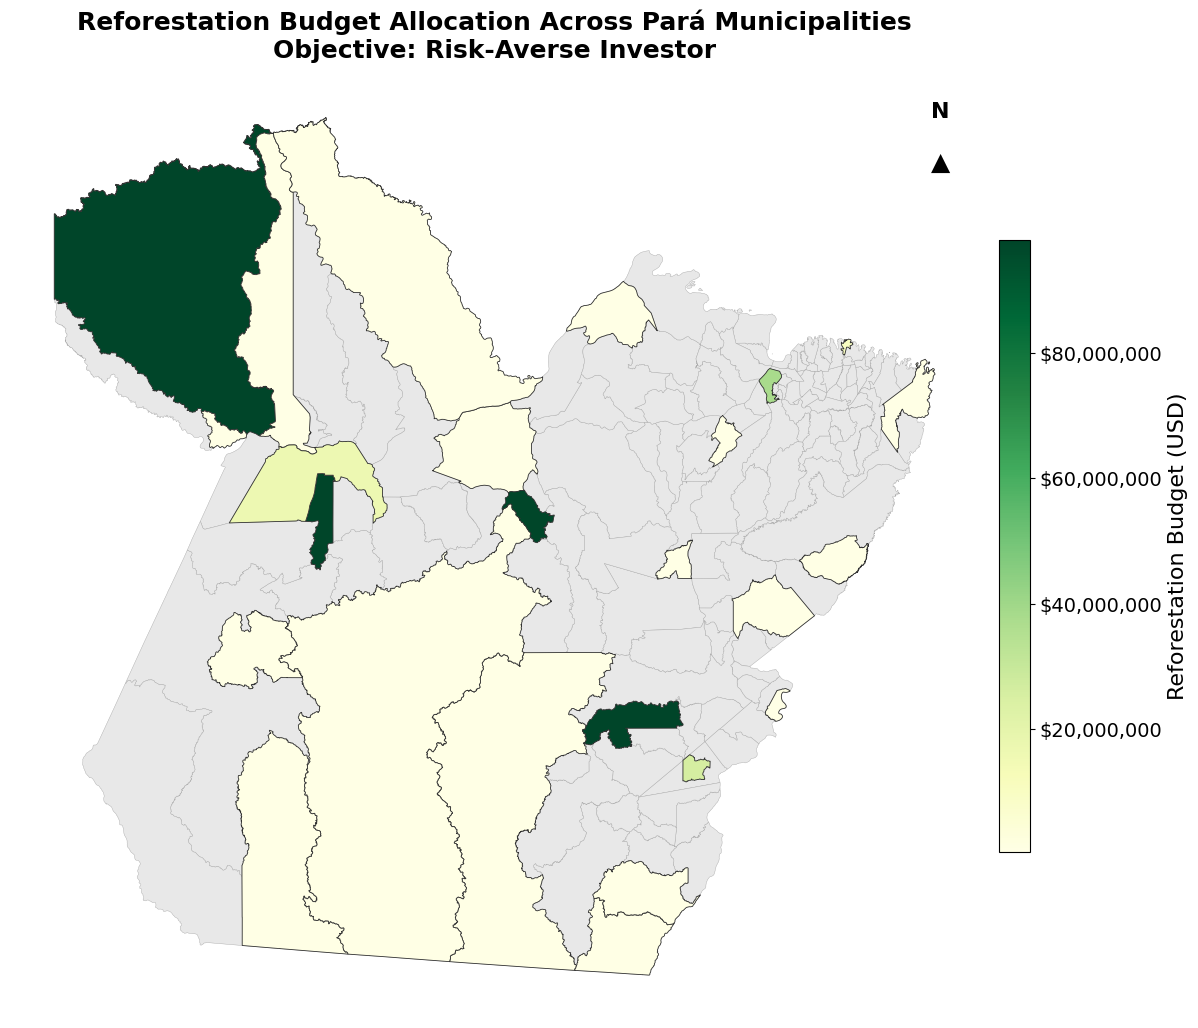

In [15]:
plot_budget_allocation_map(budget_allocation_para_municipality_graphic(alloc_df, 'Risk-Averse Investor - ', municipalities_gdf), 'Risk-Averse Investor')

## Radar Plot vs Main Lexcographic Model

In [16]:
# importing pay_off matrix for radar plot
payoff_df = pd.read_csv("Outputs\\payoff_table.csv", index_col=0)
payoff_df

,Bio_and_extinction_val,Car_val,Urg_val,Rev_val,Spatial_val
Biodiversity and Extinction,145998.502805,124695.095262,59183.776586,87859.077485,0.280907
Carbon,40017.678279,193410.001968,23882.438370,115229.042176,1.657612
Urgency,106612.747244,101693.530573,141990.933009,216855.272249,0.439335
Reversal Risk,1036.651394,5313.825487,38.212297,0.000000,3.457952
Spatial Penalty,18294.757367,104509.359591,22874.281628,96802.080686,0.086386


In [17]:
# plot radars for heuristic and milp solution only
z1_star = 140747.23  # Biodiversity & extinction risk score 
z2_star = 127860.74  # Carbon sequestration score
z3_star = 90556.79  # Urgency score
z4_star = 127082.92  # Reversal risk score
z5_star = 0.1083  # Spatial score (not optimised in MILP, but we can calculate it for the heuristic)

milp_scores = {
    'F1_biodiversity': z1_star,
    'F2_carbon': z2_star,
    'F3_urgency': z3_star,
    'F4_reversal': z4_star,
    'F5_spatial': z5_star
}

# convert to dataframe for plotting
milp_scores_df = pd.DataFrame.from_dict(milp_scores, orient='index', columns=['MILP_Score']).T
milp_scores_df


,F1_biodiversity,F2_carbon,F3_urgency,F4_reversal,F5_spatial
MILP_Score,140747.23,127860.74,90556.79,127082.92,0.1083


In [19]:
adverse_investor_scores = {
    'F1_biodiversity': actual_bio,
    'F2_carbon': actual_car,
    'F3_urgency': actual_urg,
    'F4_reversal': actual_rev,
    'F5_spatial': actual_spatial
}

# convert to dataframe for plotting
adverse_investor_scores_df = pd.DataFrame.from_dict(adverse_investor_scores, orient='index', columns=['Adverse_Investor_Score']).T
adverse_investor_scores_df


,F1_biodiversity,F2_carbon,F3_urgency,F4_reversal,F5_spatial
Adverse_Investor_Score,106963.204147,121030.880499,6383.823619,9171.382891,0.150031


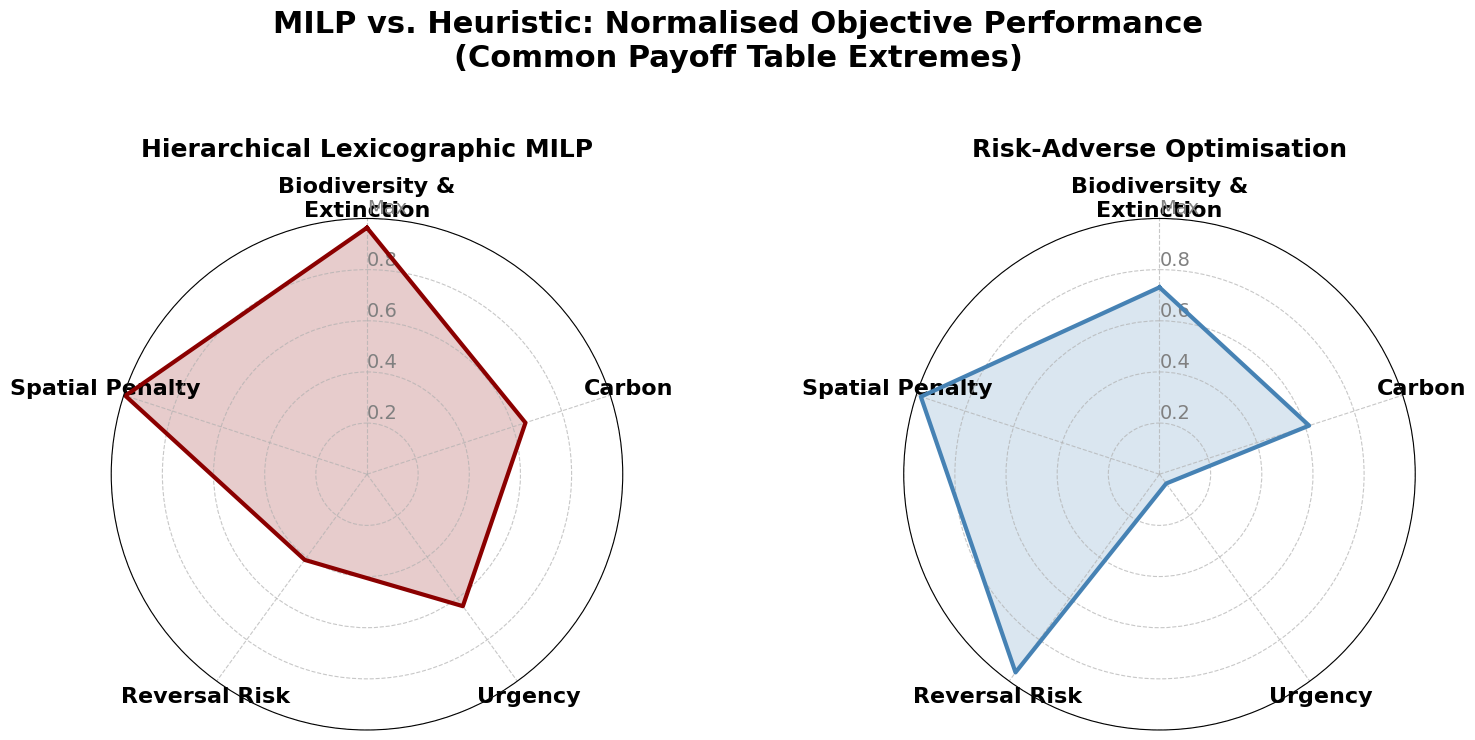

In [22]:
from math import pi
import numpy as np

# Get utopia and nadir from payoff_df for normalization (common extremes for both solutions)
bio_nadir = payoff_df['Bio_and_extinction_val'].min()
bio_utopia = payoff_df['Bio_and_extinction_val'].max()

car_nadir = payoff_df['Car_val'].min()
car_utopia = payoff_df['Car_val'].max()

urg_nadir = payoff_df['Urg_val'].min()
urg_utopia = payoff_df['Urg_val'].max()

# Minimize objectives (inverted)
rev_nadir = payoff_df['Rev_val'].max()
rev_utopia = payoff_df['Rev_val'].min()

spatial_nadir = payoff_df['Spatial_val'].max()
spatial_utopia = payoff_df['Spatial_val'].min()

# Normalize MILP scores
milp_norm_values = {}
milp_norm_values['Bio'] = (milp_scores_df['F1_biodiversity'].values[0] - bio_nadir) / (bio_utopia - bio_nadir)
milp_norm_values['Carbon'] = (milp_scores_df['F2_carbon'].values[0] - car_nadir) / (car_utopia - car_nadir)
milp_norm_values['Urgency'] = (milp_scores_df['F3_urgency'].values[0] - urg_nadir) / (urg_utopia - urg_nadir)
milp_norm_values['Reversal'] = (rev_nadir - milp_scores_df['F4_reversal'].values[0]) / (rev_nadir - rev_utopia)
milp_norm_values['Spatial'] = (spatial_nadir - milp_scores_df['F5_spatial'].values[0]) / (spatial_nadir - spatial_utopia)
milp_norm_values = {k: max(0, min(1, v)) for k, v in milp_norm_values.items()}

# Normalise Adverse Investor scores
bench_norm_values = {}
bench_norm_values['Bio'] = (adverse_investor_scores_df['F1_biodiversity'].values[0] - bio_nadir) / (bio_utopia - bio_nadir)
bench_norm_values['Carbon'] = (adverse_investor_scores_df['F2_carbon'].values[0] - car_nadir) / (car_utopia - car_nadir)
bench_norm_values['Urgency'] = (adverse_investor_scores_df['F3_urgency'].values[0] - urg_nadir) / (urg_utopia - urg_nadir)
bench_norm_values['Reversal'] = (rev_nadir - adverse_investor_scores_df['F4_reversal'].values[0]) / (rev_nadir - rev_utopia)
bench_norm_values['Spatial'] = (spatial_nadir - adverse_investor_scores_df['F5_spatial'].values[0]) / (spatial_nadir - spatial_utopia)
bench_norm_values = {k: max(0, min(1, v)) for k, v in bench_norm_values.items()}

# Setup radar chart parameters
categories = ['Biodiversity &\nExtinction', 'Carbon', 'Urgency', 'Reversal Risk', 'Spatial Penalty']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# Create side-by-side radar charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), subplot_kw=dict(polar=True))

# ─── LEFT: MILP Solution ───
ax1.set_theta_offset(pi / 2)
ax1.set_theta_direction(-1)
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories, size=16, fontweight='bold')
ax1.set_rlabel_position(0)
ax1.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax1.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "Max"], color="grey", size=14)
ax1.set_ylim(0, 1)
ax1.grid(True, linestyle='--', alpha=0.7)

milp_values = [milp_norm_values['Bio'], milp_norm_values['Carbon'], 
               milp_norm_values['Urgency'], milp_norm_values['Reversal'], milp_norm_values['Spatial']]
milp_values += milp_values[:1]
ax1.plot(angles, milp_values, color='darkred', linewidth=3, linestyle='solid')
ax1.fill(angles, milp_values, color='darkred', alpha=0.2)
ax1.set_title("Hierarchical Lexicographic MILP", size=18, fontweight='bold', pad=15)

# ─── RIGHT: Heuristic Solution ───
ax2.set_theta_offset(pi / 2)
ax2.set_theta_direction(-1)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, size=16, fontweight='bold')
ax2.set_rlabel_position(0)
ax2.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax2.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "Max"], color="grey", size=14)
ax2.set_ylim(0, 1)
ax2.grid(True, linestyle='--', alpha=0.7)

bench_values = [bench_norm_values['Bio'], bench_norm_values['Carbon'], 
                bench_norm_values['Urgency'], bench_norm_values['Reversal'], bench_norm_values['Spatial']]
bench_values += bench_values[:1]
ax2.plot(angles, bench_values, color='steelblue', linewidth=3, linestyle='solid')
ax2.fill(angles, bench_values, color='steelblue', alpha=0.2)
ax2.set_title("Risk-Adverse Optimisation", size=18, fontweight='bold', pad=15)

fig.suptitle("MILP vs. Heuristic: Normalised Objective Performance\n(Common Payoff Table Extremes)", 
             size=22, fontweight='bold', y=1.05)

plt.tight_layout()
plt.savefig("Figures/Radar Plots/Radar_MILP_vs_Adverse_Investor_Side_by_Side.png", dpi=300, bbox_inches='tight')
plt.show()

## Objective Comparison Table

Comparing main Lexicographic, heuristic and Risk-Adverse Objective Scores

In [ ]:
adverse_investor_scores
milp_scores

In [23]:
heuristic_scores = {
    'F1_biodiversity': 106680.13801266512,
    'F2_carbon': 101686.33295347224,
    'F3_urgency': 141988.,
    'F4_reversal': 216865.49271909508,
    'F5_spatial': 0.4257172581233039
}

# convert to dataframe for plotting
heuristic_scores_df = pd.DataFrame.from_dict(heuristic_scores, orient='index', columns=['Heuristic_Score']).T
heuristic_scores_df


,F1_biodiversity,F2_carbon,F3_urgency,F4_reversal,F5_spatial
Heuristic_Score,106680.138013,101686.332953,141988.0,216865.492719,0.425717


In [24]:
# import the payoff table to get the utopia and nadir values for normalization
payoff_df = pd.read_csv("Outputs\\payoff_table.csv", index_col=0)
payoff_df

,Bio_and_extinction_val,Car_val,Urg_val,Rev_val,Spatial_val
Biodiversity and Extinction,145998.502805,124695.095262,59183.776586,87859.077485,0.280907
Carbon,40017.678279,193410.001968,23882.438370,115229.042176,1.657612
Urgency,106612.747244,101693.530573,141990.933009,216855.272249,0.439335
Reversal Risk,1036.651394,5313.825487,38.212297,0.000000,3.457952
Spatial Penalty,18294.757367,104509.359591,22874.281628,96802.080686,0.086386


In [28]:
from pathlib import Path
import pandas as pd

# 1) Pull scalar values from your 1-row score DataFrames
milp = milp_scores_df.iloc[0]
heur = heuristic_scores_df.iloc[0]
adv  = adverse_investor_scores_df.iloc[0]

# 2) Build payoff-optimal column directly from payoff_df
payoff_optimal = {
    "F1: Bio & Threat (Max)": payoff_df["Bio_and_extinction_val"].max(),
    "F2: Carbon (Max)": payoff_df["Car_val"].max(),
    "F3: Urgency (Max)": payoff_df["Urg_val"].max(),
    "F4: Reversal Risk (Min)": payoff_df["Rev_val"].min(),
    "F5: Spatial Score (Min)": payoff_df["Spatial_val"].min(),
}

# 3) Build final comparison table
comparison_df = pd.DataFrame([
    {
        "Metric": "F1: Bio & Threat (Max)",
        "Payoff Optimal": payoff_optimal["F1: Bio & Threat (Max)"],
        "MILP (Lexicographic)": milp["F1_biodiversity"],
        "Heuristic (Greedy)": heur["F1_biodiversity"],
        "Risk-Adverse Investor (Lexicographic)": adv["F1_biodiversity"],
    },
    {
        "Metric": "F2: Carbon (Max)",
        "Payoff Optimal": payoff_optimal["F2: Carbon (Max)"],
        "MILP (Lexicographic)": milp["F2_carbon"],
        "Heuristic (Greedy)": heur["F2_carbon"],
        "Risk-Adverse Investor (Lexicographic)": adv["F2_carbon"],
    },
    {
        "Metric": "F3: Urgency (Max)",
        "Payoff Optimal": payoff_optimal["F3: Urgency (Max)"],
        "MILP (Lexicographic)": milp["F3_urgency"],
        "Heuristic (Greedy)": heur["F3_urgency"],
        "Risk-Adverse Investor (Lexicographic)": adv["F3_urgency"],
    },
    {
        "Metric": "F4: Reversal Risk (Min)",
        "Payoff Optimal": payoff_optimal["F4: Reversal Risk (Min)"],
        "MILP (Lexicographic)": milp["F4_reversal"],
        "Heuristic (Greedy)": heur["F4_reversal"],
        "Risk-Adverse Investor (Lexicographic)": adv["F4_reversal"],
    },
    {
        "Metric": "F5: Spatial Score (Min)",
        "Payoff Optimal": payoff_optimal["F5: Spatial Score (Min)"],
        "MILP (Lexicographic)": milp["F5_spatial"],
        "Heuristic (Greedy)": heur["F5_spatial"],
        "Risk-Adverse Investor (Lexicographic)": adv["F5_spatial"],
    },
])

# 4) Save CSV
comparison_df.to_csv("Outputs\objective_comparison_payoff_milp_heuristic.csv", index=False)
comparison_df

,Metric,Payoff Optimal,MILP (Lexicographic),Heuristic (Greedy),Risk-Adverse Investor (Lexicographic)
0,F1: Bio & Threat (Max),145998.502805,140747.2300,106680.138013,106963.204147
1,F2: Carbon (Max),193410.001968,127860.7400,101686.332953,121030.880499
2,F3: Urgency (Max),141990.933009,90556.7900,141988.000000,6383.823619
3,F4: Reversal Risk (Min),0.000000,127082.9200,216865.492719,9171.382891
4,F5: Spatial Score (Min),0.086386,0.1083,0.425717,0.150031
